<a href="https://colab.research.google.com/github/NatalieAleksandrova2026/DTA_2026/blob/main/ML/ml_practice_LR%26Cl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практика: лінійна регресія та класифікація

Це тренувальний блокнот для закріплення базового циклу ML. Завдання **нескладні** й повторюють кроки з основного тьюторіалу — тільки тепер усе робиш **сам**.

**Дві задачі на двох нових наборах даних:**
- **Задача A (регресія):** передбачити **зарплату** працівника.
- **Задача B (класифікація):** передбачити, чи **складе студент іспит** (так/ні).

**Як працювати:**
1. Запусти комірку «Підготовка даних» нижче — вона все налаштує.
2. Іди по кроках. Там, де стоїть `# TODO`, — впиши свій код.
3. Підказки є під кожним кроком.

> 💡 Усі потрібні інструменти ти вже бачив: `train_test_split`, `LinearRegression`, `DecisionTreeClassifier`, `.fit()`, `.predict()`, метрики. Тримай той блокнот поруч як шпаргалку.

---

## 🔧 Підготовка даних (просто запусти)

In [1]:
# ▶️ Просто запусти цю комірку — вона готує дані. Міняти нічого не треба.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 20)

# ---------- Дані A: ЗАРПЛАТИ (для регресії) ----------
N = 800
experience = np.random.randint(0, 31, N)                      # стаж, років
age        = (22 + experience + np.random.randint(0, 12, N)).clip(22, 64)  # вік
education  = np.random.choice([12, 15, 16, 18, 20], N,        # років освіти
                              p=[.2, .15, .35, .2, .1])
english    = np.random.randint(1, 6, N)                       # рівень англ. 1..5

salary = (8000                       # базова ставка, грн
          + experience * 900         # за кожен рік стажу
          + education  * 600         # за рік освіти
          + english    * 1500        # за рівень англійської
          + np.random.normal(0, 3000, N)   # шум: усе інше
         ).clip(8000, None)

salary_df = pd.DataFrame({
    "experience": experience, "age": age,
    "education": education, "english": english,
    "salary": salary.round(0).astype(int),
})

# ---------- Дані B: СТУДЕНТИ (для класифікації) ----------
M = 800
study     = np.random.normal(12, 5, M).clip(0, 30)            # годин навчання/тиждень
attendance= np.random.normal(78, 15, M).clip(30, 100)        # відвідуваність, %
prev_score= np.random.normal(65, 18, M).clip(0, 100)         # бал за минулий іспит
sleep     = np.random.normal(7, 1.2, M).clip(4, 10)          # годин сну

score_logit = (0.12*study + 0.04*attendance + 0.05*prev_score
               + 0.3*sleep - 9 + np.random.normal(0, 1.2, M))
passed = (score_logit > 0).astype(int)                        # 1 = склав, 0 = ні

students_df = pd.DataFrame({
    "study": study.round(1), "attendance": attendance.round(0).astype(int),
    "prev_score": prev_score.round(0).astype(int), "sleep": sleep.round(1),
    "passed": passed,
})

print("✅ Дані готові.")
print("Зарплати:", salary_df.shape, "| Студенти:", students_df.shape)
print("Частка тих, хто склав іспит:", f"{students_df['passed'].mean():.0%}")

✅ Дані готові.
Зарплати: (800, 5) | Студенти: (800, 5)
Частка тих, хто склав іспит: 69%


---
# 🟦 Задача A. Регресія: передбачаємо зарплату

Дані у таблиці `salary_df`. Ознаки: `experience` (стаж), `age` (вік), `education` (років освіти), `english` (рівень англійської 1–5). Ціль: `salary` (зарплата, грн).

Мета — навчити модель передбачати зарплату і **пояснити**, що на неї впливає.

### Крок A1. Подивись на дані
Виведи перші рядки таблиці й описову статистику. Це звичка №1 перед будь-яким навчанням.

*Підказка:* `salary_df.head()` і `salary_df.describe()`.

In [2]:
# TODO: виведи перші рядки salary_df
salary_df.head()

,experience,age,education,english,salary
0,6,32,15,2,23714
1,19,44,12,3,32814
2,28,54,12,5,54472
3,14,42,20,5,35964
4,10,40,18,2,29723


In [3]:
# TODO: виведи describe()
salary_df.describe()

,experience,age,education,english,salary
count,800.000000,800.000000,800.000000,800.000000,800.000000
mean,15.418750,42.746250,15.856250,3.028750,36028.926250
std,9.328568,9.924338,2.408908,1.432826,9242.043432
min,0.000000,22.000000,12.000000,1.000000,12917.000000
25%,7.000000,35.000000,15.000000,2.000000,28550.750000
50%,16.000000,43.000000,16.000000,3.000000,36102.500000
75%,24.000000,51.000000,18.000000,4.000000,43545.500000
max,30.000000,62.000000,20.000000,5.000000,55947.000000


### Крок A2. Признач ознаки (X) і ціль (y), поділи на train / test
- `X` — усі стовпці, КРІМ `salary`.
- `y` — стовпець `salary`.
- Поділ: 20% у тест, `random_state=RANDOM_STATE`.

*Підказка:* `X = salary_df[["experience", "age", "education", "english"]]`,
`y = salary_df["salary"]`, далі `train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)`.

In [4]:
salary_df.columns

Index(['experience', 'age', 'education', 'english', 'salary'], dtype='object')

In [5]:
from sklearn.model_selection import train_test_split

# TODO: створи X та y
X =salary_df[['experience', 'age', 'education', 'english']]
y = salary_df['salary']

# TODO: поділи на X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print('Train:', X_train.shape[0], '| Test:', X_test.shape[0])

# print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])

Train: 640 | Test: 160


### Крок A3. Навчи лінійну регресію
Згадай цикл: **створити → `.fit(X_train, y_train)`**.

*Підказка:* `from sklearn.linear_model import LinearRegression`, далі `model = LinearRegression()` і `model.fit(...)`.

In [6]:
from sklearn.linear_model import LinearRegression

# TODO: створи та навчи модель
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
compare = pd.DataFrame({
    'real_salary': y_test[:5].round(2),
    'predict_salary': y_pred[:5].round(2)
})
compare

compare['error'] = (compare['predict_salary'] - compare['real_salary']).round(2)
compare

,real_salary,predict_salary,error
696,31948,35434.02,3486.02
667,24556,27081.19,2525.19
63,26426,27857.87,1431.87
533,37535,36863.00,-672.00
66,33494,36475.93,2981.93


### Крок A4. Зроби передбачення й оціни якість
- Передбач на `X_test`.
- Порахуй **MAE** та **R²**.

*Підказка:* `y_pred = model.predict(X_test)`; `mean_absolute_error(y_test, y_pred)`;
`r2_score(y_test, y_pred)`.

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_pred = model.predict(X_test)
# TODO: передбач y_pred
# TODO: порахуй і виведи MAE та R²
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f'MAE = {mae:.1f} K $ error in average')
print(f"MSE = {mse:.1f}")
print(f'RMSE = {rmse:.1f} K $')
print(f'R2 = {r2:.3f} (the model shows {r2 * 100:.1f}% price shift)')


MAE = 2545.3 K $ error in average
MSE = 9770492.7
RMSE = 3125.8 K $
R2 = 0.881 (the model shows 88.1% price shift)


### Крок A5. 🔑 Інтерпретуй коефіцієнти
Дістань коефіцієнти моделі й скажи словами, яка ознака найсильніше підвищує зарплату.

*Підказка:* `model.coef_` і `model.intercept_`. Зістав назви з `X.columns`.

In [8]:
# TODO: побудуй таблицю "ознака — коефіцієнт" і відсортуй
coefs = pd.DataFrame({
    'features': X.columns,
    'coef': model.coef_.round(2)
}).sort_values('coef', key=abs, ascending=False)

print(f'Basic salary: {model.intercept_:.2f} K $\n')
print('How those features influence the salary')
display(coefs)

Basic salary: 6850.03 K $

How those features influence the salary


,features,coef
3,english,1597.45
0,experience,872.48
2,education,609.59
1,age,31.15


✍️ **Запиши відповідь словами** (просто текстом у цій комірці, подвійний клік):
> Найсильніше на зарплату впливає ознака ___, бо ___.

In [9]:
print('The strongest influence on salary is the english feature (coef. +1597.45),')
print('because knowledge of English gives the highest salary boost —')
print('on average +1597 K$ compared to other features.')
print()
print('Second place goes to experience (+872.48) — each year of experience')
print('adds approximately 872 K$ to the salary.')
print()
print('Age (age, +31.15) has almost no impact — the coefficient is very small.')

The strongest influence on salary is the english feature (coef. +1597.45),
because knowledge of English gives the highest salary boost —
on average +1597 K$ compared to other features.

Second place goes to experience (+872.48) — each year of experience
adds approximately 872 K$ to the salary.

Age (age, +31.15) has almost no impact — the coefficient is very small.


### Крок A6. Передбач зарплату для нового працівника
Створи одного працівника й передбач його зарплату: стаж 5, вік 30, освіта 16, англійська 4.

*Підказка:* зроби `pd.DataFrame([{...}])` з тими самими назвами стовпців і передай у `model.predict(...)`.

In [13]:
salary_df.columns

Index(['experience', 'age', 'education', 'english', 'salary'], dtype='object')

In [14]:
# TODO: створи new_employee і передбач зарплату
new_employee = pd.DataFrame([{
    'experience': 5,
    'age': 30,
    'education': 16,
    'english': 4,
}])

new_employee

,experience,age,education,english
0,5,30,16,4


In [15]:
print(f"New employee will have salary {model.predict(new_employee)[0]:.2f} $ +- {mae:.2f}  $")

New employee will have salary 28290.19 $ +- 2545.33  $


In [16]:
salary_df.head()

,experience,age,education,english,salary
0,6,32,15,2,23714
1,19,44,12,3,32814
2,28,54,12,5,54472
3,14,42,20,5,35964
4,10,40,18,2,29723


---
# 🟩 Задача B. Класифікація: чи складе студент іспит

Дані у таблиці `students_df`. Ознаки: `study` (годин навчання/тиждень), `attendance` (відвідуваність %), `prev_score` (бал за минулий іспит), `sleep` (годин сну). Ціль: `passed` (1 = склав, 0 = ні).

### Крок B1. Подивись на дані
Виведи перші рядки й перевір баланс класів: яка частка студентів склала іспит?

*Підказка:* `students_df.head()` і `students_df["passed"].mean()`.

In [18]:
# TODO: head() і частка тих, хто склав
students_df.head()

,study,attendance,prev_score,sleep,passed
0,11.2,76,94,5.7,1
1,18.5,72,49,9.4,1
2,15.7,71,59,7.9,0
3,16.1,100,88,5.1,1
4,9.9,92,72,7.0,1


In [19]:
students_df['passed'].mean()

np.float64(0.69375)

In [20]:
print(f'Table size: {students_df.shape[0]} rows x {students_df.shape[1]} columns')
print('/nIs there any missing spaces?')
print(students_df.isna().sum())
students_df.describe().round(2)

Table size: 800 rows x 5 columns
/nIs there any missing spaces?
study         0
attendance    0
prev_score    0
sleep         0
passed        0
dtype: int64


,study,attendance,prev_score,sleep,passed
count,800.00,800.00,800.00,800.00,800.00
mean,12.05,77.30,64.81,7.05,0.69
std,4.91,14.22,16.91,1.23,0.46
min,0.00,35.00,10.00,4.00,0.00
25%,8.80,67.00,53.00,6.20,0.00
50%,11.90,78.00,65.00,7.10,1.00
75%,15.50,88.25,77.00,7.90,1.00
max,25.40,100.00,100.00,10.00,1.00


### Крок B2. X, y і поділ на train / test
- `X` — усе, крім `passed`. `y` — `passed`.
- Додай `stratify=y`, щоб пропорція класів збереглася.

*Підказка:* `train_test_split(Xs, ys, test_size=0.2, random_state=RANDOM_STATE, stratify=ys)`.

In [21]:
students_df.columns

Index(['study', 'attendance', 'prev_score', 'sleep', 'passed'], dtype='object')

In [29]:
# TODO: Xs, ys та поділ на Xs_train, Xs_test, ys_train, ys_test
from sklearn.model_selection import train_test_split


Xs = students_df[['study', 'attendance', 'prev_score', 'sleep']]
ys = students_df['passed']

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    Xs, ys,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=ys
)

print('Passing print: ', Xs_train.shape[0], 'students')
print('Passing print: ', Xs_test.shape[0], 'students')

Passing print:  640 students
Passing print:  160 students


### Крок B3. Навчи дерево рішень
Використай `DecisionTreeClassifier` з `max_depth=3` (щоб було просте й читабельне) і `random_state=RANDOM_STATE`.

*Підказка:* `from sklearn.tree import DecisionTreeClassifier`.

In [27]:
from sklearn.tree import DecisionTreeClassifier

# TODO: створи та навчи дерево
model_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=RANDOM_STATE
)

model_tree.fit(Xs_train, ys_train)
ys_pred = model_tree.predict(Xs_test)

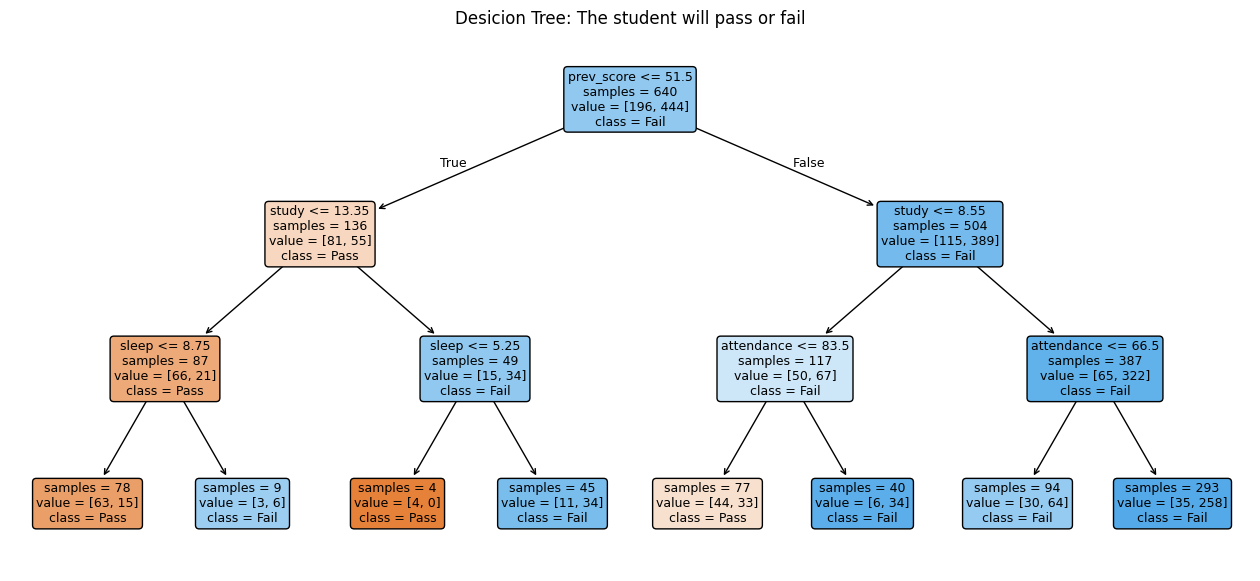

In [32]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16,7))
plot_tree(
    model_tree,
    feature_names=Xs.columns,
    class_names=['Pass', 'Fail'],
    filled=True, rounded=True, fontsize=9, impurity=False
)

plt.title('Desicion Tree: The student will pass or fail')
plt.show()

### Крок B4. Передбач і оціни
- Передбач на `Xs_test`.
- Порахуй **accuracy** і побудуй **матрицю плутанини**.

*Підказка:* `accuracy_score(ys_test, ys_pred)` та `confusion_matrix(ys_test, ys_pred)`.

In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# TODO: передбач ys_pred, порахуй accuracy та матрицю плутанини
acc = accuracy_score(ys_test, ys_pred)
print(f"Accuracy = {acc:.2%}\n")

cm = confusion_matrix(ys_test, ys_pred)
students_df_cm = pd.DataFrame(
    cm,
    index=['Really passed', 'Really failed'],
    columns=['Predicted pass', 'Predicted fail']
)

print('Confusion Matrix:')
display(students_df_cm)


print("\nDetailed report:")
print(classification_report(ys_test, ys_pred, target_names=['Pass', 'Fail']))

Accuracy = 75.62%

Confusion Matrix:


,Predicted pass,Predicted fail
Really passed,25,24
Really failed,15,96



Detailed report:
              precision    recall  f1-score   support

        Pass       0.62      0.51      0.56        49
        Fail       0.80      0.86      0.83       111

    accuracy                           0.76       160
   macro avg       0.71      0.69      0.70       160
weighted avg       0.75      0.76      0.75       160



### Крок B5. Що найбільше впливає на результат?
Виведи важливість ознак дерева й назви найважливішу.

*Підказка:* `tree.feature_importances_`, зістав із `Xs.columns`.

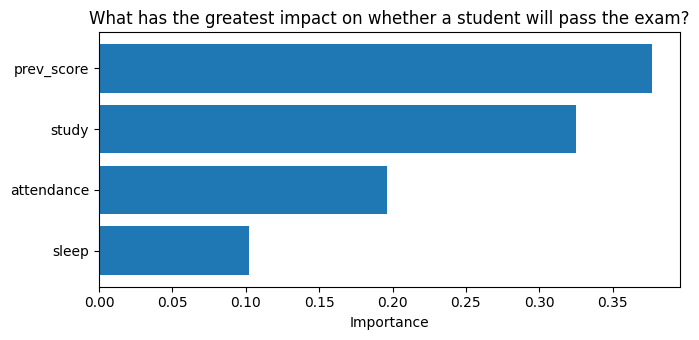

,features,importances
3,sleep,0.102
1,attendance,0.196
0,study,0.325
2,prev_score,0.377


In [38]:
# TODO: таблиця "ознака — важливість", відсортована за спаданням
importances = pd.DataFrame({
    "features": Xs.columns,
    "importances": model_tree.feature_importances_.round(3)
}).sort_values("importances", ascending=True)

plt.figure(figsize=(7, 3.5))
plt.barh(importances["features"], importances["importances"])

plt.xlabel("Importance")
plt.title('What has the greatest impact on whether a student will pass the exam?')
plt.tight_layout()
plt.show()

importances

✍️ **Відповідь словами:**
> The most important feature — prev_score (0.377) — the previous score has the strongest impact on the current result.   
In second place is study (0.325) — the number of study hours.   
sleep (0.102) has the least impact.

### Крок B6. Передбач для нового студента
Студент: навчання 15 год, відвідуваність 85%, минулий бал 70, сон 7.5.
Виведи і рішення (`predict`), і **ймовірність** скласти (`predict_proba`).

*Підказка:* `predict_proba(...)[0, 1]` — це ймовірність класу «склав».

In [39]:
students_df.columns

Index(['study', 'attendance', 'prev_score', 'sleep', 'passed'], dtype='object')

In [44]:
# TODO: створи new_student, виведи рішення та ймовірність
new_student = pd.DataFrame([{
    'study': 15,
    'attendance': 85,
    'prev_score': 70,
    'sleep': 7.5
}])

new_student

,study,attendance,prev_score,sleep
0,15,85,70,7.5


In [45]:
print(f"Probability pass: {model_tree.predict_proba(new_student)[0, 1]:.2%}")
print(f"Decision: {'Fail' if model_tree.predict(new_student)[0] else 'Pass'}")
print("\n----------")
print(f"Result accuracy: {accuracy_score(ys_test, ys_pred):.2%}")


Probability pass: 88.05%
Decision: Fail

----------
Result accuracy: 75.62%


---
# ⭐ Бонус (необов'язково, але корисно)

1. **Перевір на перенавчання.** Для дерева зі Задачі B порахуй accuracy окремо на `Xs_train` і на `Xs_test`. Великий розрив = зубріння. Потім спробуй `max_depth=10` — розрив зросте?
2. **Сильніша модель.** Навчи `RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)` на тих самих даних і порівняй accuracy з деревом.
3. **Прибери ознаку.** У Задачі A прибери `experience` з `X`, перенавчи й подивись, як впаде R². Який висновок про важливість стажу?

In [46]:
# Місце для бонусних експериментів
train_acc = accuracy_score(ys_train, model_tree.predict(Xs_train))
test_acc  = accuracy_score(ys_test, ys_pred)

print(f'max_depth=3:')
print(f'  Train accuracy: {train_acc:.2%}')
print(f'  Test accuracy:  {test_acc:.2%}')
print(f'  GAP:         {(train_acc - test_acc):.2%}')


max_depth=3:
  Train accuracy: 79.22%
  Test accuracy:  75.62%
  GAP:         3.59%


In [47]:
model_tree10 = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)
model_tree10.fit(Xs_train, ys_train)

train_acc10 = accuracy_score(ys_train, model_tree10.predict(Xs_train))
test_acc10  = accuracy_score(ys_test, model_tree10.predict(Xs_test))

print(f'\nmax_depth=10:')
print(f'  Train accuracy: {train_acc10:.2%}')
print(f'  Test accuracy:  {test_acc10:.2%}')
print(f'  GAP:         {(train_acc10 - test_acc10):.2%}')


max_depth=10:
  Train accuracy: 97.03%
  Test accuracy:  71.88%
  GAP:         25.16%


max_depth=3 — all good:

Gap only 3.59% — model generalizes well
Test accuracy 75.62% — acceptable

max_depth=10 — classic overfitting:

Train accuracy 97% — model memorized every training example
Test accuracy dropped to 71.88% — performs worse on new data
Gap 25.16% — huge, model is memorizing not learning

Conclusion: a deep tree memorizes every training example including noise and random patterns. This does not work on new data. max_depth=3 is the best choice for this dataset.

In [48]:
from sklearn.ensemble import RandomForestClassifier

model_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=RANDOM_STATE
)

model_forest.fit(Xs_train, ys_train)
ys_pred_rf = model_forest.predict(Xs_test)

print(f"Desicion Tree: accuracy = {accuracy_score(ys_test, ys_pred):.2%}")
print(f"Random Forest: accuracy = {accuracy_score(ys_test, ys_pred_rf):.2%}")

Desicion Tree: accuracy = 75.62%
Random Forest: accuracy = 78.12%


Random Forest outperforms a single tree by 2.5% — this is expected.
Why the forest beats the tree:

One tree — one perspective on the data
200 trees — 200 different perspectives, final answer by voting

Errors of one tree are compensated by others — so the result is more stable and accurate.

---
# 🧠 Питання на розуміння (без коду)

Дай собі відповідь словами:
1. Чому ми оцінюємо модель на `X_test`, а не на `X_train`?
2. Задача «передбачити кількість проданих квитків» — це регресія чи класифікація? А «спам / не спам»?
3. Що означає R² = 0.85 простими словами?
4. Чому accuracy може бути оманливою, якщо лише 5% студентів провалюють іспит?
5. Коефіцієнт `english = +1500`. Як прочитати це вголос для керівника?


✍️ **Відповідь словами:**

1. Ми оцінюємо на X_test тому що модель ніколи не бачила цих даних.
   Якщо тестувати на X_train — модель покаже ідеальний результат,
   бо вона вже запам'ятала ці приклади. X_test показує як модель
   працює на реальних нових даних.
2. Передбачити кількість квитків — РЕГРЕСІЯ (число).
   Спам / не спам — КЛАСИФІКАЦІЯ (категорія).
3. R² = 0.85 означає що модель пояснює 85% варіації зарплати.
   Простими словами: якщо знаєш досвід, вік, освіту та англійську —
   можеш передбачити зарплату з точністю 85%.
   Решта 15% залежить від факторів яких немає в даних.
4. Якщо лише 5% студентів провалюють іспит, модель яка завжди
   передбачає ЗДАВ отримає accuracy = 95% — але жодного разу
   не впіймає студента який провалиться.
   Висока точність але абсолютно марна модель.
   В таких випадках краще дивитись на recall та F1-score.
5. Коефіцієнт english = +1500:
   За інших рівних умов працівник який знає англійську
   заробляє в середньому на 1500$ більше на місяць
   ніж той хто не знає.

> 🎯 Якщо впорався із задачами A і B без ШІ — ти впевнено володієш базовим циклом ML. Вітаю!